## Learning goals

By the end of this lesson, you should be able to:

- explain how a kernel measures similarity;
- distinguish a classical feature map from a quantum feature map;
- train both classifiers on the same data; and
- interpret the comparison without claiming a quantum advantage.

::: {.callout-note}
This notebook assumes familiarity with SVMs and kernel functions. If you are new to these topics, read the [Support Vector Machines](1.0-svm.ipynb) and [Kernels in SVMs](2.0-kernel.ipynb) notebooks first.
:::

::: {.callout-important}
This notebook runs the quantum circuit on a classical statevector simulator. It is a teaching example, not a performance benchmark or evidence of quantum advantage.
:::

## 1. The classification problem

A binary classification dataset contains feature vectors and labels

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{N},
\qquad \mathbf{x}_i\in\mathbb{R}^d,\quad y_i\in\{0,1\}.
$$

A classifier learns a function $f:\mathbb{R}^d\rightarrow\{0,1\}$ from a training subset. We evaluate it on data that was not used for fitting.

In [1]:
#| label: setup
#| include: false

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

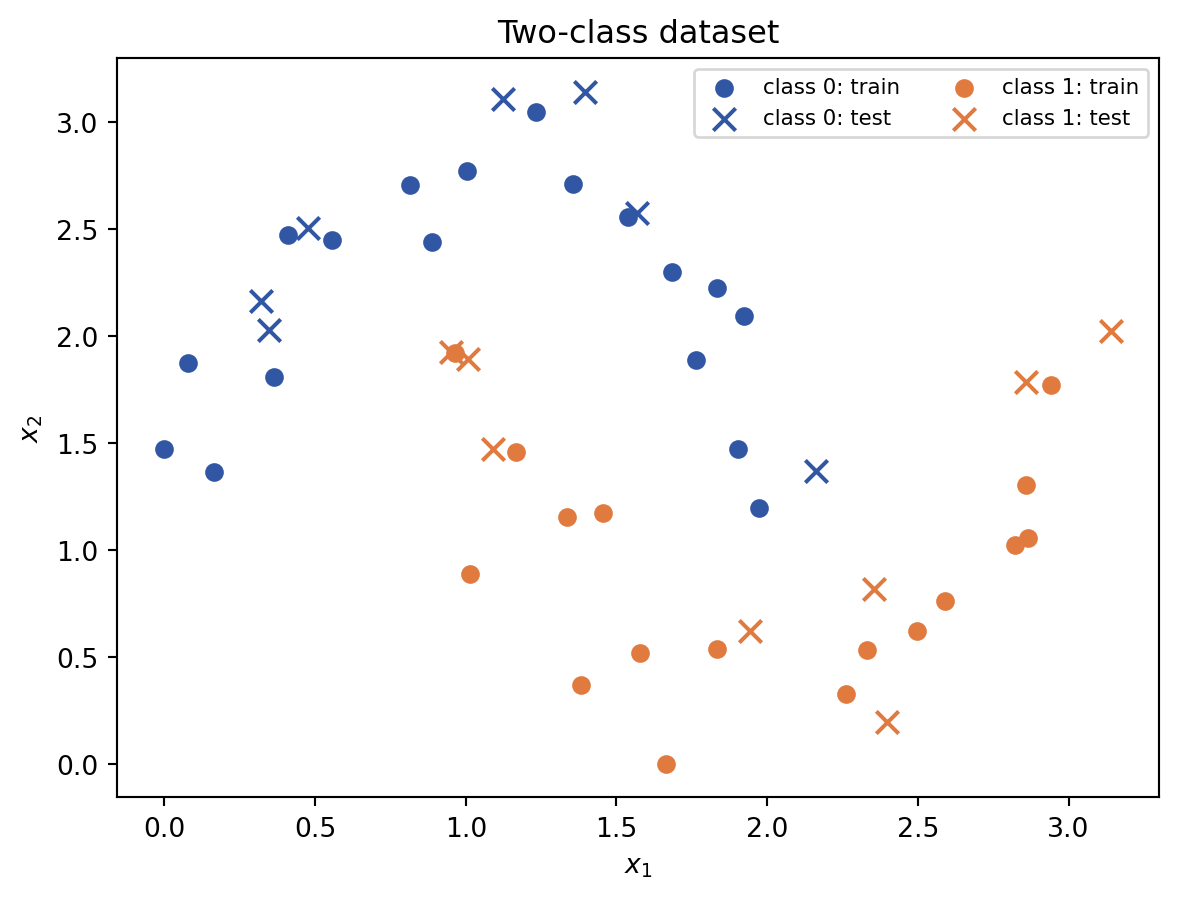

In [2]:
#| label: fig-data
#| fig-cap: "The same training and test observations are used for both classifiers."

X, y = make_moons(n_samples=50, noise=0.12, random_state=RANDOM_SEED)
X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [(0, "#3157a4"), (1, "#e07a3f")]:
    ax.scatter(*X_train[y_train == label].T, c=color, marker="o", label=f"class {label}: train")
    ax.scatter(*X_test[y_test == label].T, c=color, marker="x", s=70, label=f"class {label}: test")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Two-class dataset")
ax.legend(ncols=2, fontsize=8)
plt.show()

## 2. Classical kernel classifier

A kernel computes similarity without requiring us to explicitly construct every coordinate of a feature map $\phi$:

$$
k(\mathbf{x},\mathbf{z})
=\langle\phi(\mathbf{x}),\phi(\mathbf{z})\rangle.
$$

We use the radial-basis-function kernel

$$
k_{\mathrm{RBF}}(\mathbf{x},\mathbf{z})
=\exp\!\left(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2\right).
$$

Nearby observations have a kernel value close to $1$; distant observations have a value closer to $0$.

In [3]:
classical_model = SVC(kernel="rbf", gamma="scale")
classical_model.fit(X_train, y_train)
classical_predictions = classical_model.predict(X_test)
classical_accuracy = accuracy_score(y_test, classical_predictions)

print(f"Classical test accuracy: {classical_accuracy:.3f}")

Classical test accuracy: 0.800


## 3. Quantum feature map and kernel

A parameterized quantum circuit $U_\phi(\mathbf{x})$ encodes a classical vector as a quantum state:

$$
|\phi(\mathbf{x})\rangle
=U_\phi(\mathbf{x})|0\rangle^{\otimes n}.
$$

The quantum kernel is the squared overlap between two encoded states:

$$
k_Q(\mathbf{x},\mathbf{z})
=\left|\langle\phi(\mathbf{x})|\phi(\mathbf{z})\rangle\right|^2.
$$

The support-vector optimization remains classical. The quantum part supplies the kernel matrix.

In [4]:
#| label: fig-feature-map
#| fig-cap: "A two-qubit ZZ feature map encodes the two input features."

from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement="linear")
print(feature_map.draw(output="text", fold=90))

   ┌───┐┌───────────┐                                          ┌───┐┌───────────┐     »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├┤ P(2*x[0]) ├──■──»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐├───┤├───────────┤┌─┴─┐»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├┤ H ├┤ P(2*x[1]) ├┤ X ├»
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘└───┘└───────────┘└───┘»
«                                        
«0: ──────────────────────────────────■──
«   ┌──────────────────────────────┐┌─┴─┐
«1: ┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
«   └──────────────────────────────┘└───┘


In [5]:
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

# Exact classical simulation of quantum states: no hardware account required.
quantum_kernel = FidelityStatevectorKernel(feature_map=feature_map)
quantum_model = QSVC(quantum_kernel=quantum_kernel)
quantum_model.fit(X_train, y_train)
quantum_predictions = quantum_model.predict(X_test)
quantum_accuracy = accuracy_score(y_test, quantum_predictions)

print(f"Quantum-kernel test accuracy: {quantum_accuracy:.3f}")

Quantum-kernel test accuracy: 0.867


## 4. Inspect the quantum kernel matrix

For training observations $\mathbf{x}_1,\ldots,\mathbf{x}_m$, the matrix

$$
K_{ij}=k_Q(\mathbf{x}_i,\mathbf{x}_j)
$$

contains every pairwise similarity supplied to the support-vector algorithm. The diagonal is $1$ because each state has perfect overlap with itself.

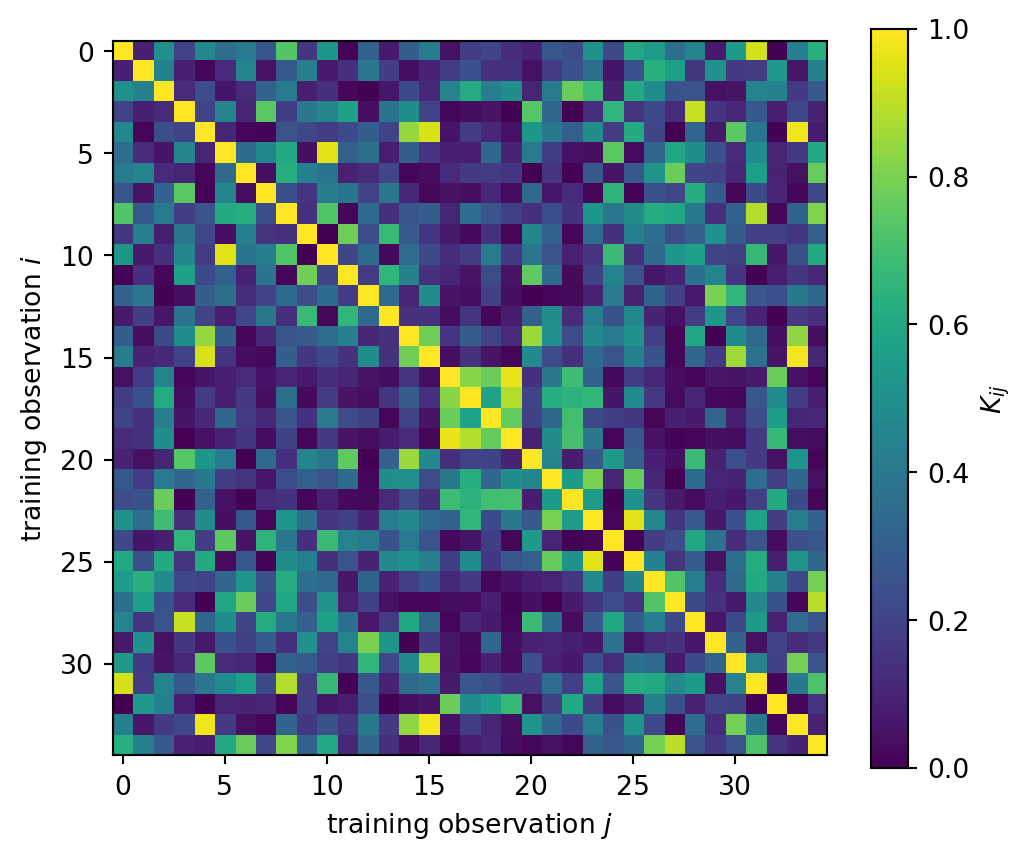

In [6]:
#| label: fig-kernel
#| fig-cap: "Quantum kernel matrix for the training observations."

K_train = quantum_kernel.evaluate(X_train)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(K_train, vmin=0, vmax=1, cmap="viridis")
ax.set(xlabel="training observation $j$", ylabel="training observation $i$")
fig.colorbar(image, ax=ax, label="$K_{ij}$")
plt.show()

## 5. Compare the results

Accuracy is

$$
\operatorname{accuracy}
=\frac{\text{number of correct predictions}}
{\text{number of test observations}}.
$$

Because this test set is deliberately small, one changed prediction can noticeably change the score. Treat the result as an illustration, not a general ranking.

In [7]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "classifier": ["Classical RBF SVC", "Quantum-kernel QSVC"],
        "test accuracy": [classical_accuracy, quantum_accuracy],
        "kernel source": ["Classical formula", "Simulated two-qubit circuit"],
    }
)
comparison

,classifier,test accuracy,kernel source
0,Classical RBF SVC,0.800000,Classical formula
1,Quantum-kernel QSVC,0.866667,Simulated two-qubit circuit


### What can we conclude?

- Both models use the same observations, split, labels, and support-vector learning principle.
- They differ in how similarity is computed.
- The quantum model is simulated by a classical computer here, so it cannot provide a runtime advantage.
- A result on one tiny dataset does not establish that either kernel is generally superior.

## Try it yourself

1. Change `RANDOM_SEED` and rerun every cell.
2. Increase `noise` in `make_moons`.
3. Change the feature-map repetitions from `reps=2` to `reps=1` or `reps=3`.
4. Record how accuracy and the quantum kernel matrix change.

These experiments separate stable mathematical definitions from results that depend on data and modeling choices.